# 02 — VAR (Vector Autoregression)

VAR models all variables as jointly endogenous — each variable is regressed on its own
lags and the lags of every other variable. Unlike ARIMAX (where gold/USD are exogenous
inputs), VAR treats silver, gold, USD, copper and S&P500 returns as a system and lets
the data decide how they influence each other.

Key outputs beyond forecasting:
- **Lag order selection** (AIC/BIC)
- **Granger causality tests** — formally tests whether other variables help predict silver
- **Impulse response functions** — how a shock to one variable propagates through the system
- **Walk-forward forecast** with same DA/WDA metrics as other notebooks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

## 1. Load and aggregate to weekly

In [2]:
# Weekly feature frame (built once by 02_features.ipynb §8 — single source of truth).
weekly = pd.read_csv('../../data/processed/features_weekly.csv', index_col=0, parse_dates=True)

# VAR endogenous variables — all treated symmetrically (W-FRI-summed returns in the frame).
COLS = ['silver_return', 'gold_return', 'usd_return', 'copper_return', 'sp500_return']
all_w   = weekly[COLS].dropna()
n_train = int((weekly.loc[all_w.index, 'split'] != 'test').sum())

print(f'Weekly obs — train+val: {n_train}, test: {len(all_w) - n_train}')
all_w.head()

Weekly obs — train+val: 417, test: 174


,silver_return,gold_return,usd_return,copper_return,sp500_return
week_end,,,,,
2015-01-09,0.040603,0.024980,0.009398,-0.017055,-0.006527
2015-01-16,0.079338,0.048869,0.006289,-0.050153,-0.012495
2015-01-23,0.030261,0.012220,0.026452,-0.044889,0.015917
2015-01-30,-0.061582,-0.010968,-0.002107,-0.003751,-0.028088
2015-02-06,-0.030354,-0.035508,-0.001055,0.029236,0.029865


## 2. Lag order selection

Fit VAR on the training set and select lag order by AIC and BIC.
BIC penalises extra lags more heavily — usually gives a more parsimonious model.

In [3]:
model_sel = VAR(all_w.iloc[:n_train])
lag_results = model_sel.select_order(maxlags=10)
print(lag_results.summary())

best_lag_aic = lag_results.aic
best_lag_bic = lag_results.bic
print(f'\nSelected lag — AIC: {best_lag_aic},  BIC: {best_lag_bic}')
LAG = max(best_lag_bic, 1)  # use BIC; floor at 1
print(f'Using lag: {LAG}')

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -39.85*     -39.80*  4.955e-18*     -39.83*
1       -39.84      -39.55   4.978e-18      -39.72
2       -39.79      -39.25   5.224e-18      -39.58
3       -39.77      -38.98   5.344e-18      -39.46
4       -39.72      -38.69   5.605e-18      -39.31
5       -39.72      -38.44   5.608e-18      -39.22
6       -39.70      -38.17   5.742e-18      -39.10
7       -39.65      -37.87   6.069e-18      -38.94
8       -39.57      -37.56   6.524e-18      -38.78
9       -39.54      -37.27   6.770e-18      -38.64
10      -39.47      -36.96   7.238e-18      -38.48
--------------------------------------------------

Selected lag — AIC: 0,  BIC: 0
Using lag: 1


## 3. Granger causality tests

Tests whether lagged values of each variable significantly improve forecasts of silver
beyond silver's own history. A significant result (p < 0.05) means the variable
Granger-causes silver — it adds predictive information.

Note: Granger causality is about predictability, not economic causality.

In [4]:
train_data = all_w.iloc[:n_train]

print(f'Granger causality → silver_return (maxlags={LAG}):')
print('-' * 55)
for col in [c for c in COLS if c != 'silver_return']:
    # grangercausalitytests needs [target, predictor] order
    gc_data = train_data[['silver_return', col]].dropna()
    res = grangercausalitytests(gc_data, maxlag=LAG, verbose=False)
    # Use F-test p-value at the selected lag
    p = res[LAG][0]['ssr_ftest'][1]
    sig = '*' if p < 0.05 else ''
    print(f'  {col:<20}  p={p:.4f}  {sig}')
print('\n* p < 0.05 — variable Granger-causes silver')

Granger causality → silver_return (maxlags=1):
-------------------------------------------------------
  gold_return           p=0.4432  
  usd_return            p=0.4602  
  copper_return         p=0.4771  
  sp500_return          p=0.2074  

* p < 0.05 — variable Granger-causes silver


### 3a. Granger causality for sentiment

Tests whether weekly-aggregated Reddit and news sentiment Granger-cause silver returns.
Two horizons are reported (lag 1 and lag 4) because sentiment effects can be delayed —
the H0 of no Granger causality is rejected if *any* lag of the predictor is informative.

Reverse direction (silver → sentiment) is reported too as a falsification check: if
silver returns drive sentiment more than the other way around, the "sentiment is a
leading signal" framing is weaker.

In [5]:
# Granger causality: does weekly sentiment help predict silver_return (and the reverse)?
# Sentiment weekly means come from the frame (02_features §8).
sent_w = weekly[["reddit_sentiment", "news_sentiment"]]

# Align with the training window only — keep test untouched.
gc_frame = train_data.join(sent_w, how="inner").dropna()
print(f"Granger-causality sample: {len(gc_frame)} weeks ({gc_frame.index.min().date()} -> {gc_frame.index.max().date()})\n")

LAGS_TO_TEST = [1, 2, 4]

def run_gc(y_col, x_col, lags):
    pvals = {}
    d = gc_frame[[y_col, x_col]].dropna()
    res = grangercausalitytests(d, maxlag=max(lags), verbose=False)
    for L in lags:
        pvals[L] = res[L][0]["ssr_ftest"][1]
    return pvals

def fmt_row(name, pvals):
    cells = []
    for L in LAGS_TO_TEST:
        p = pvals[L]
        star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        cells.append(f"L={L}: p={p:.3f} {star:<3}")
    print(f"  {name:<28}  " + "   ".join(cells))

print("Sentiment -> silver_return  (does sentiment help predict silver?)")
print("-" * 80)
for s in ["reddit_sentiment", "news_sentiment"]:
    fmt_row(s, run_gc("silver_return", s, LAGS_TO_TEST))

print("\nFalsification -- silver_return -> sentiment  (reverse causality?)")
print("-" * 80)
for s in ["reddit_sentiment", "news_sentiment"]:
    fmt_row(s, run_gc(s, "silver_return", LAGS_TO_TEST))

print("\n* p<0.05  ** p<0.01  *** p<0.001   (F-test, OLS-fitted VAR residuals)")

Granger-causality sample: 232 weeks (2017-10-13 -> 2022-12-30)

Sentiment -> silver_return  (does sentiment help predict silver?)
--------------------------------------------------------------------------------
  reddit_sentiment              L=1: p=0.591       L=2: p=0.880       L=4: p=0.615    
  news_sentiment                L=1: p=0.489       L=2: p=0.382       L=4: p=0.834    

Falsification -- silver_return -> sentiment  (reverse causality?)
--------------------------------------------------------------------------------
  reddit_sentiment              L=1: p=0.660       L=2: p=0.469       L=4: p=0.607    
  news_sentiment                L=1: p=0.431       L=2: p=0.044 *     L=4: p=0.100    

* p<0.05  ** p<0.01  *** p<0.001   (F-test, OLS-fitted VAR residuals)


## 4. Impulse response functions

How does a one-standard-deviation shock to each variable affect silver return over the
next 10 weeks? Shaded area = 95% confidence interval.

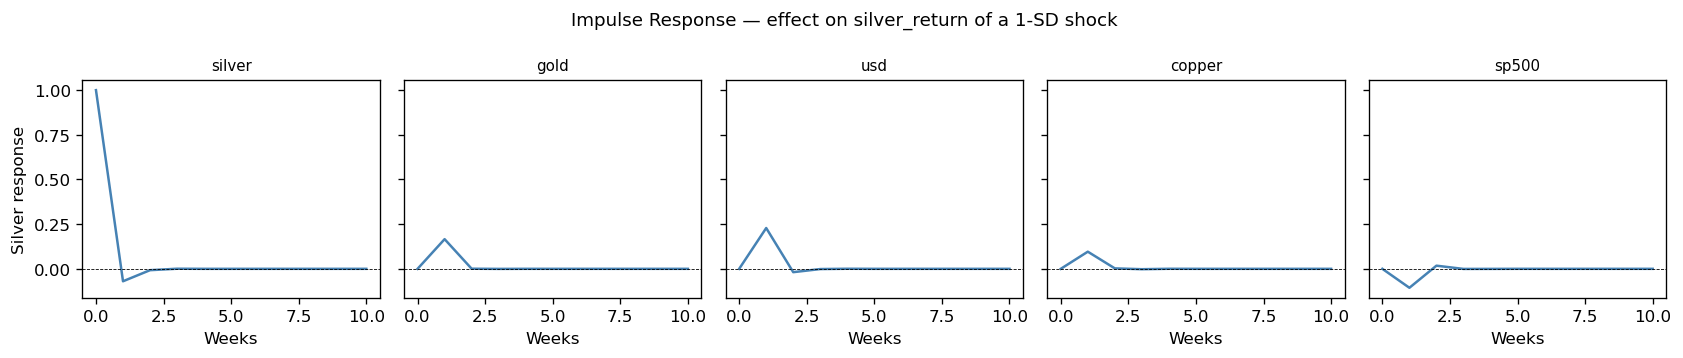

In [6]:
fitted = VAR(train_data).fit(LAG)
irf = fitted.irf(periods=10)

silver_idx = COLS.index('silver_return')
fig, axes = plt.subplots(1, len(COLS), figsize=(14, 3), sharey=True)

for j, col in enumerate(COLS):
    # Response of silver (row silver_idx) to shock in col (column j)
    response = irf.irfs[:, silver_idx, j]
    lower    = irf.cum_effect_stderr(orth=False)  # skip — use plot method instead
    axes[j].plot(response, color='steelblue', lw=1.5)
    axes[j].axhline(0, color='black', lw=0.5, ls='--')
    axes[j].set_title(col.replace('_return', ''), fontsize=9)
    axes[j].set_xlabel('Weeks')

axes[0].set_ylabel('Silver response')
fig.suptitle('Impulse Response — effect on silver_return of a 1-SD shock', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Walk-forward forecast

At each test week $t$ we refit VAR on all weeks before $t$ (expanding window) and
predict one step ahead. Only the silver equation's forecast is evaluated.

In [7]:
WINDOW = 100  # rolling window size — set to None for expanding

silver_col = COLS.index('silver_return')

def var_walk_forward(all_w, n_train, lag, window=None):
    """window=None → expanding; window=N → rolling (last N weeks)."""
    preds = np.full(len(all_w) - n_train, np.nan)
    for i, t in enumerate(range(n_train, len(all_w))):
        start   = max(0, t - window) if window else 0
        history = all_w.iloc[start:t]
        try:
            model = VAR(history).fit(lag)
            fc    = model.forecast(history.values[-lag:], steps=1)
            preds[i] = fc[0, silver_col]
        except Exception:
            pass
    return preds

print('Running VAR — expanding window...')
preds_exp = var_walk_forward(all_w, n_train, LAG, window=None)
print('Running VAR — rolling window (100 weeks)...')
preds_rol = var_walk_forward(all_w, n_train, LAG, window=WINDOW)
print(f'Expanding: {(~np.isnan(preds_exp)).sum()} forecasts')
print(f'Rolling:   {(~np.isnan(preds_rol)).sum()} forecasts')
preds = preds_exp  # default used downstream

Running VAR — expanding window...


Running VAR — rolling window (100 weeks)...
Expanding: 174 forecasts
Rolling:   174 forecasts


## 6. Evaluate

In [8]:
import sys, os
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import evaluate, period_metrics, diebold_mariano, PERIODS

y_test     = all_w['silver_return'].iloc[n_train:].values
test_index = all_w.index[n_train:]

naive_pred = all_w['silver_return'].iloc[n_train-1:-1].values

metrics = []
metrics.append(evaluate('Naive (t-1 week)',            y_test[1:], naive_pred[1:]))
metrics.append(evaluate(f'VAR({LAG}) expanding',       y_test, preds_exp))
metrics.append(evaluate(f'VAR({LAG}) rolling (100w)',  y_test, preds_rol))

metrics_df = pd.DataFrame([m for m in metrics if m is not None])
metrics_df.to_csv('../../data/processed/metrics_var.csv', index=False)
metrics_df

Naive (t-1 week)                               RMSE=0.07594  MAE=0.05397  DA=0.491  WDA=0.490
VAR(1) expanding                               RMSE=0.05229  MAE=0.03758  DA=0.511  WDA=0.514
VAR(1) rolling (100w)                          RMSE=0.05353  MAE=0.03889  DA=0.420  WDA=0.441


,model,rmse,mae,dir_acc,wda
0,Naive (t-1 week),0.075941,0.053966,0.491329,0.489862
1,VAR(1) expanding,0.052292,0.037578,0.511494,0.514270
2,VAR(1) rolling (100w),0.053531,0.038891,0.419540,0.441133


## 7. Predicted vs actual

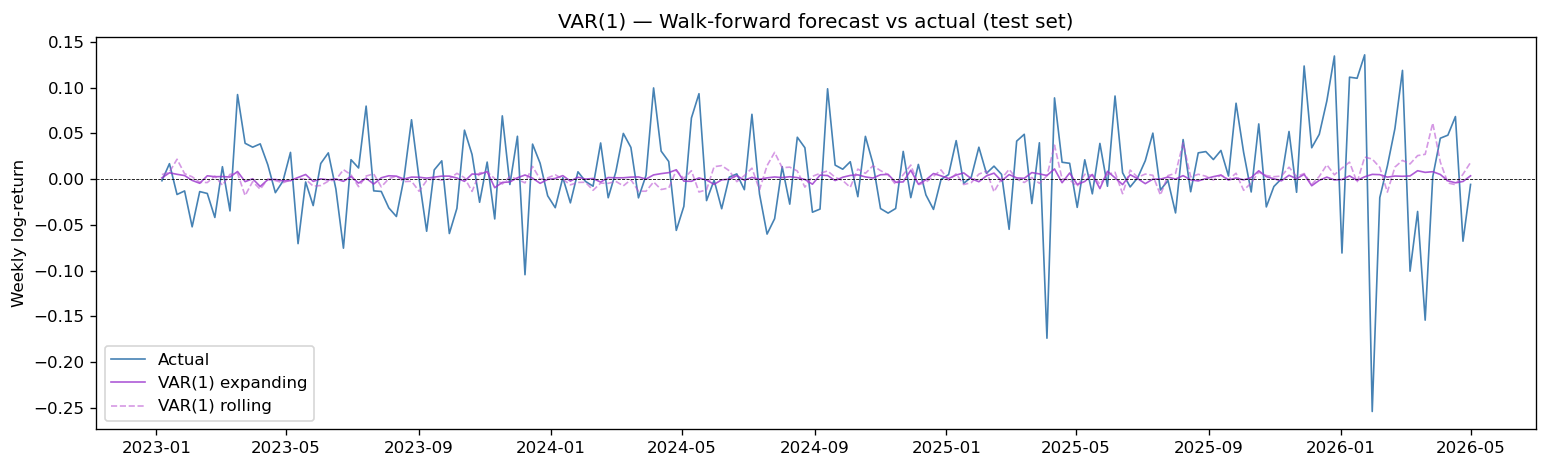

In [9]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_index, y_test, lw=1,   label='Actual',       color='steelblue')
ax.plot(test_index, preds_exp, lw=1, label=f'VAR({LAG}) expanding', color='darkorchid', alpha=0.8)
ax.plot(test_index, preds_rol, lw=1, label=f'VAR({LAG}) rolling',   color='mediumorchid', alpha=0.6, ls='--')
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_title(f'VAR({LAG}) — Walk-forward forecast vs actual (test set)')
ax.set_ylabel('Weekly log-return')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Sentiment comparison

Adds lagged Reddit and news sentiment as endogenous variables in the VAR system.
Lag order is re-selected on each augmented dataset. Silver forecasts are compared
across three specifications: no sentiment, Reddit + News, news only (GDELT).

In [10]:
# Sentiment-augmented VAR variants. Sentiment weekly means from the frame (02_features §8).
sent_w = weekly[["reddit_sentiment", "news_sentiment"]]
all_candidates = {
    "VAR expanding":      preds_exp,
    "VAR rolling (100w)": preds_rol,
}

def var_sentiment_run(all_w, n_train, sent_cols, label):
    sent_aligned = sent_w[sent_cols].reindex(all_w.index).ffill().fillna(0)
    all_aug = pd.concat([all_w, sent_aligned], axis=1).dropna()
    try:
        lag_sel = VAR(all_aug.iloc[:n_train]).select_order(maxlags=8)
        lag = max(lag_sel.bic, 1)
    except Exception:
        lag = LAG
    silver_col_aug = all_aug.columns.tolist().index("silver_return")
    p_exp = np.full(len(all_aug) - n_train, np.nan)
    p_rol = np.full(len(all_aug) - n_train, np.nan)
    for i, t in enumerate(range(n_train, len(all_aug))):
        for window, out in [(None, p_exp), (100, p_rol)]:
            start   = max(0, t - window) if window else 0
            history = all_aug.iloc[start:t]
            try:
                m  = VAR(history).fit(lag)
                fc = m.forecast(history.values[-lag:], steps=1)
                out[i] = fc[0, silver_col_aug]
            except Exception:
                pass
    y_t = all_aug["silver_return"].iloc[n_train:].values
    idx = all_aug.index[n_train:]
    print("--- {} ---".format(label))
    evaluate("{} expanding".format(label),      y_t, p_exp)
    evaluate("{} rolling (100w)".format(label), y_t, p_rol)
    all_candidates["{} expanding".format(label)]      = p_exp
    all_candidates["{} rolling (100w)".format(label)] = p_rol

print("Baseline (no sentiment):")
evaluate("VAR expanding",      y_test, preds_exp)
evaluate("VAR rolling (100w)", y_test, preds_rol)
print()
print("Running VAR + Reddit + News...")
var_sentiment_run(all_w, n_train, ["reddit_sentiment", "news_sentiment"], "Reddit+News")
print()
print("Running VAR + Reddit only...")
var_sentiment_run(all_w, n_train, ["reddit_sentiment"], "Reddit only")
print()
print("Running VAR + News only (GDELT)...")
var_sentiment_run(all_w, n_train, ["news_sentiment"], "News only")
print()

Baseline (no sentiment):
VAR expanding                                  RMSE=0.05229  MAE=0.03758  DA=0.511  WDA=0.514
VAR rolling (100w)                             RMSE=0.05353  MAE=0.03889  DA=0.420  WDA=0.441

Running VAR + Reddit + News...


--- Reddit+News ---
Reddit+News expanding                          RMSE=0.05215  MAE=0.03740  DA=0.506  WDA=0.551
Reddit+News rolling (100w)                     RMSE=0.05402  MAE=0.03916  DA=0.483  WDA=0.539

Running VAR + Reddit only...


--- Reddit only ---
Reddit only expanding                          RMSE=0.05233  MAE=0.03764  DA=0.489  WDA=0.496
Reddit only rolling (100w)                     RMSE=0.05404  MAE=0.03927  DA=0.460  WDA=0.497

Running VAR + News only (GDELT)...


--- News only ---
News only expanding                            RMSE=0.05211  MAE=0.03735  DA=0.500  WDA=0.543
News only rolling (100w)                       RMSE=0.05353  MAE=0.03875  DA=0.494  WDA=0.535



## Sub-period robustness: DA and WDA by year

Breaks down the best-performing variant by calendar year to check whether
the result is stable across different market regimes.

In [11]:
best_name = max(all_candidates, key=lambda k:
    np.nansum(np.abs(y_test) * (np.sign(y_test) == np.sign(all_candidates[k]))) /
    np.nansum(np.abs(y_test)))
best_pred = all_candidates[best_name]
print("Best variant by WDA:", best_name)
res = period_metrics(y_test, best_pred, test_index, PERIODS)
display(res[["n", "DA", "WDA"]].style
        .format({"n": "{:.0f}", "DA": "{:.3f}", "WDA": "{:.3f}"})
        .background_gradient(cmap="RdYlGn", subset=["DA", "WDA"], vmin=0.4, vmax=0.7))

res[['n', 'DA', 'WDA']].to_csv('../../data/processed/period_var_weekly.csv')

Best variant by WDA: Reddit+News expanding


,n,DA,WDA
Period,,,
2023 (choppy),52,0.500,0.553
2024 (bull start),52,0.558,0.592
2025 (bull run),52,0.404,0.478
2026 (YTD),18,0.667,0.601
── Full test ──,174,0.506,0.551


## Diebold-Mariano test

Tests whether sentiment variants produce statistically significant forecast improvements
over the no-sentiment baseline. H0: equal predictive accuracy (squared error loss).
p < 0.05 = significant improvement.

In [12]:
print("Diebold-Mariano tests — each variant vs no-sentiment baseline")
print("H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant")
print("-" * 90)

baseline_key  = "VAR expanding"
baseline_pred = all_candidates[baseline_key]
for name, pred in all_candidates.items():
    if name == baseline_key:
        continue
    diebold_mariano(y_test, baseline_pred, pred, baseline_key, name)

Diebold-Mariano tests — each variant vs no-sentiment baseline
H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant
------------------------------------------------------------------------------------------
VAR expanding                            vs VAR rolling (100w)                        DM=-1.473  p=0.141  (ns)  -> winner: tie
VAR expanding                            vs Reddit+News expanding                     DM=+0.616  p=0.538  (ns)  -> winner: tie
VAR expanding                            vs Reddit+News rolling (100w)                DM=-1.444  p=0.149  (ns)  -> winner: tie
VAR expanding                            vs Reddit only expanding                     DM=-1.244  p=0.214  (ns)  -> winner: tie
VAR expanding                            vs Reddit only rolling (100w)                DM=-1.792  p=0.073  (ns)  -> winner: tie
VAR expanding                            vs News only expanding                       DM=+0.837  p=0.403  (ns)  -> winner: ti

## 2026 zoom — actual vs best model

Focuses on the most recent out-of-sample period where silver has been most active.
Uses the best-performing variant selected earlier.

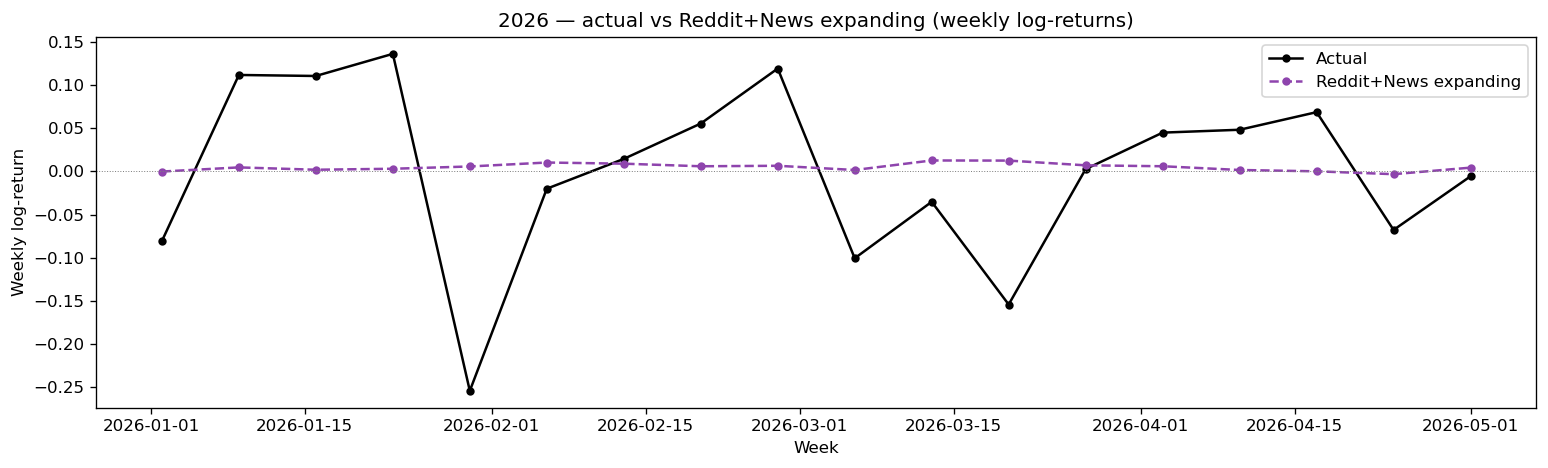

In [13]:
df26 = pd.DataFrame({"actual": y_test, "pred": best_pred}, index=test_index)
df26 = df26.loc["2026":]

if df26.empty:
    print("No 2026 data in test set yet.")
else:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(df26.index, df26["actual"], color="black",  lw=1.5, marker="o", ms=4, label="Actual")
    ax.plot(df26.index, df26["pred"],   color="#8e44ad", lw=1.5, marker="o", ms=4,
            ls="--", label=f"{best_name}")
    ax.axhline(0, color="grey", lw=0.6, ls=":")
    ax.set_title(f"2026 — actual vs {best_name} (weekly log-returns)", fontsize=12)
    ax.set_ylabel("Weekly log-return")
    ax.set_xlabel("Week")
    ax.legend()
    plt.tight_layout()
    plt.show()